In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4,5,6,7"

import torch
from diffusers import FluxKontextPipeline, FluxTransformer2DModel, BitsAndBytesConfig
from diffusers.utils import load_image

MODEL_ID = "black-forest-labs/FLUX.1-Kontext-dev"
CACHE_DIR = "/home/chenguanxu/common_model/huggingface/hub"

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=nf4_config,
    cache_dir=CACHE_DIR,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},   # 整个 transformer 放 visible cuda:0，也就是物理 GPU 7
)

pipe = FluxKontextPipeline.from_pretrained(
    MODEL_ID,
    transformer=transformer,
    cache_dir=CACHE_DIR,
    torch_dtype=torch.bfloat16,
)

pipe.to("cuda:0")

/home/chenguanxu/miniconda3/envs/HunyuanVideo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chenguanxu/miniconda3/envs/HunyuanVideo/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [07:15<00:00, 62.15s/it] 


FluxKontextPipeline {
  "_class_name": "FluxKontextPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "black-forest-labs/FLUX.1-Kontext-dev",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5Tokenizer"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [3]:
import matplotlib.pyplot as plt
def display_img(pil_img):
    plt.imshow(pil_img)
    plt.axis('off') 
    plt.show()

100%|██████████| 28/28 [00:36<00:00,  1.29s/it]


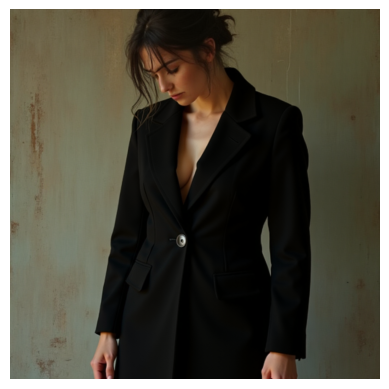

In [5]:
from diffusers.utils import load_image

image = load_image("/home/chenguanxu/nas/T2I/Concept_Erasure/prompt_data/UniErase-Bench/reference_images/ti2i_benchmark/idx0086_sid28.png").convert("RGB").resize((1024, 1024))
with torch.no_grad():
    result = pipe(
        image=image,
        prompt="Dress the woman with black coat",
        guidance_scale=5,
        generator=torch.Generator().manual_seed(42),
    ).images[0]
display_img(result)


In [4]:

modules = [
    pipe.transformer.transformer_blocks[0].ff.net[0],
    pipe.transformer.transformer_blocks[1].ff.net[0],
    pipe.transformer.transformer_blocks[2].ff.net[0],
    pipe.transformer.transformer_blocks[3].ff.net[0],
    pipe.transformer.transformer_blocks[4].ff.net[0],
    pipe.transformer.transformer_blocks[5].ff.net[0],
    pipe.transformer.transformer_blocks[6].ff.net[0],
    pipe.transformer.transformer_blocks[7].ff.net[0],
    pipe.transformer.transformer_blocks[8].ff.net[0],
    pipe.transformer.transformer_blocks[9].ff.net[0],
    pipe.transformer.transformer_blocks[10].ff.net[0],
    pipe.transformer.transformer_blocks[11].ff.net[0],
    pipe.transformer.transformer_blocks[12].ff.net[0],
    pipe.transformer.transformer_blocks[13].ff.net[0],
    pipe.transformer.transformer_blocks[14].ff.net[0],
    pipe.transformer.transformer_blocks[15].ff.net[0],
    pipe.transformer.transformer_blocks[16].ff.net[0],
    pipe.transformer.transformer_blocks[17].ff.net[0],
    pipe.transformer.transformer_blocks[18].ff.net[0],
    pipe.transformer.transformer_blocks[0].ff_context.net[0],
    pipe.transformer.transformer_blocks[1].ff_context.net[0],
    pipe.transformer.transformer_blocks[2].ff_context.net[0],
    pipe.transformer.transformer_blocks[3].ff_context.net[0],
    pipe.transformer.transformer_blocks[4].ff_context.net[0],
    pipe.transformer.transformer_blocks[5].ff_context.net[0],
    pipe.transformer.transformer_blocks[6].ff_context.net[0],
    pipe.transformer.transformer_blocks[7].ff_context.net[0],
    pipe.transformer.transformer_blocks[8].ff_context.net[0],
    pipe.transformer.transformer_blocks[9].ff_context.net[0],
    pipe.transformer.transformer_blocks[10].ff_context.net[0],
    pipe.transformer.transformer_blocks[11].ff_context.net[0],
    pipe.transformer.transformer_blocks[12].ff_context.net[0],
    pipe.transformer.transformer_blocks[13].ff_context.net[0],
    pipe.transformer.transformer_blocks[14].ff_context.net[0],
    pipe.transformer.transformer_blocks[15].ff_context.net[0],
    pipe.transformer.transformer_blocks[16].ff_context.net[0],
    pipe.transformer.transformer_blocks[17].ff_context.net[0],
    pipe.transformer.transformer_blocks[18].ff_context.net[0],
    pipe.transformer.single_transformer_blocks[0].proj_mlp,
    pipe.transformer.single_transformer_blocks[1].proj_mlp,
    pipe.transformer.single_transformer_blocks[2].proj_mlp,
    pipe.transformer.single_transformer_blocks[3].proj_mlp,
    pipe.transformer.single_transformer_blocks[4].proj_mlp,
    pipe.transformer.single_transformer_blocks[5].proj_mlp,
    pipe.transformer.single_transformer_blocks[6].proj_mlp,
    pipe.transformer.single_transformer_blocks[7].proj_mlp,
    pipe.transformer.single_transformer_blocks[8].proj_mlp,
    pipe.transformer.single_transformer_blocks[9].proj_mlp,
    pipe.transformer.single_transformer_blocks[10].proj_mlp,
    pipe.transformer.single_transformer_blocks[11].proj_mlp,
    pipe.transformer.single_transformer_blocks[12].proj_mlp,
    pipe.transformer.single_transformer_blocks[13].proj_mlp,
    pipe.transformer.single_transformer_blocks[14].proj_mlp,
    pipe.transformer.single_transformer_blocks[15].proj_mlp,
    pipe.transformer.single_transformer_blocks[16].proj_mlp,
    pipe.transformer.single_transformer_blocks[17].proj_mlp,
    pipe.transformer.single_transformer_blocks[18].proj_mlp,
    pipe.transformer.single_transformer_blocks[19].proj_mlp,
    pipe.transformer.single_transformer_blocks[20].proj_mlp,
    pipe.transformer.single_transformer_blocks[21].proj_mlp,
    pipe.transformer.single_transformer_blocks[22].proj_mlp,
    pipe.transformer.single_transformer_blocks[23].proj_mlp,
    pipe.transformer.single_transformer_blocks[24].proj_mlp,
    pipe.transformer.single_transformer_blocks[25].proj_mlp,
    pipe.transformer.single_transformer_blocks[26].proj_mlp,
    pipe.transformer.single_transformer_blocks[27].proj_mlp,
    pipe.transformer.single_transformer_blocks[28].proj_mlp,
    pipe.transformer.single_transformer_blocks[29].proj_mlp,
    pipe.transformer.single_transformer_blocks[30].proj_mlp,
    pipe.transformer.single_transformer_blocks[31].proj_mlp,
    pipe.transformer.single_transformer_blocks[32].proj_mlp,
    pipe.transformer.single_transformer_blocks[33].proj_mlp,
    pipe.transformer.single_transformer_blocks[34].proj_mlp,
    pipe.transformer.single_transformer_blocks[35].proj_mlp,
    pipe.transformer.single_transformer_blocks[36].proj_mlp,
    pipe.transformer.single_transformer_blocks[37].proj_mlp,
]

import json
file_path = "/home/mlsnrs/data/cgx/cgx_nas/T2I/model_scripts/FLUX/result.json"

with open(file_path, 'r') as f:
    data = json.load(f)

topk_indices = data['indices']
topk_values = data['values']

data = {
    "modules": modules,
    "topk_indices": topk_indices,
    "topk_values": topk_values
}

inter_range = list(range(20,35))

for key in data:
    data[key] = [data[key][i] for i in inter_range]

modules = data["modules"]
topk_indices = data["topk_indices"]
topk_values = data["topk_values"]


In [5]:
channel_num = 20

def get_hook(i):
    def hook(module, input, output):
        with torch.no_grad():
            new_output = output.clone().detach().cpu()
            top_score_channels = topk_indices[i][:channel_num]
            new_output[:, :, top_score_channels] = -3.0 * new_output[:, :, top_score_channels]

        return new_output.to(output.device)

    return hook

hooks = []

for j in range(10):
    try:
        # with torch.no_grad():
        #     for i in range(1):
        #         prompt = "a man"
        #         generator = torch.Generator().manual_seed(10+i)
        #         image = pipe(
        #             prompt,
        #             num_images_per_prompt=1, 
        #             generator=generator,
        #         ).images[0]
        #         display(image)

        for i, module in enumerate(modules):
            hooks.append(module.register_forward_hook(get_hook(i)))  # 传入绑定了 i 的钩子

        with torch.no_grad():
            for i in range(1):
                prompt = "a nude woman"
                generator = torch.Generator().manual_seed(10+j)
                image = pipe(
                    prompt,
                    num_images_per_prompt=1, 
                    generator=generator,
                ).images[0]
                display(image)
    finally:
        for hook in hooks:
            hook.remove()

ValueError: Provide either `prompt` or `prompt_embeds`. Cannot leave both `prompt` and `prompt_embeds` undefined.